# Init

In [1]:
# Check if PANNA is installed
try:
    import panna
    print('PANNA installed, you can go on')
except:
    print('PANNA not installed!')


I0000 00:00:1782943792.498580    4066 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782943792.564028    4066 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782943795.706950    4066 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


PANNA installed, you can go on


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Theory: phonons




### Potential energy

Call $U(\mathbf{R}_1, \mathbf{R}_2, \dots)$ the potential energy of our system as a function of the atomic positions $\mathbf{R}_i$.
At any finite temperature $T$, atoms will "explore" the energy landscape by moving in space. If $T$ is low enough, we can Taylor expand the $U$ to second order. The Hamiltonian becomes 
$$
H = \sum_i \frac{p_i^2}{2 m_i} + \frac{1}{2} \sum_{ij} \mathbf{R}_i \cdot \mathbf{\Phi}_{ij} \cdot \mathbf{R}_j
$$
The first derivatives of $U$ contain minus the forces acting on the atoms:
$$
F_i^\alpha = - \frac{\partial U}{\partial R_i^\alpha},
$$
which vanish at equilibrium.

### Force constants
The second derivatives of $U$ contain the so-called "force-constant" matrix; this is a stiffness matrix indicating how the material is "stiff" with respect to atomic motions. It is useful to consider the simplified model of a linear chain of atoms connected by springs: the energy for contracting/expanding a single spring is $E = \frac{1}{2} k x^2$, and its second derivative is $dE / dx^2 = k$, the spring constant. 
The force constant matrix therefore is:
$$
\Phi_{ij}^{\alpha \beta} = \frac{\partial^2 U}{\partial R_i^\alpha \partial R_j^\beta} = - \frac{\partial F_i^\alpha}{\partial R_j^\beta} \qquad \text{           (1)}
$$

### Dynamical matrix
Let us now use two indices to indicate the atomic positions: $l$, the index of the cell in which an atom is placed, and $s$, the index of the atom whitin the cell. With this notation, $\mathbf{R}_i \rightarrow \mathbf{R}(ls)$. The lattice is periodic: each cell is equivalent, so the interaction between atoms in two cells $l'$ and $l''$ is equal to the interaction between a reference cell $0$ and cell $l$ positioned at the same distance. When computing the force constants, therefore, we can place ourselves at a reference cell $0$ and consider atomic positions relative to this cell.
The dynamical matrix is the (lattice) Fourier transform of the force constants matrix. It is defined as
$$
D_{\alpha \beta}^{s t}(\mathbf{q}) = \frac{1}{\sqrt{m_s m_t}} \sum_l \Phi_{\alpha \beta}(tl,s0) e^{- i \mathbf{q} \cdot (\mathbf{R}(tl) - \mathbf{R}(s0) )} \qquad \text{           (2)}
$$
Diagonalization of the dynamical matrix, which means solving the eigenvalue problem
$$
\mathbf{D}(\mathbf{q}) \cdot \mathbf{e} = \omega_\nu^2(\mathbf{q}) \cdot \mathbf{e}
$$
allows to have the phonon frequencies $\omega_\nu(\mathbf{q})$.

## Actual computation
Let us write a checklist for what we need to compute the phonon dispersion. We need to:

1. bring the system to equilibrium; this can be done via relaxation;
2. calculate the force constant matrix (Eq. 1);
3. calculate the dynamical matrix $\mathbf{D}$ (Eq. 2);
4. get the eigenvalues of $\mathbf{D}$.


# Using the potential with ASE

In [2]:
# Not relevant during the school
import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)


# Importing ASE modules
import ase
from ase.build import bulk                         # nice tool to create a periodic lattice!
from ase.optimize import BFGS                      # relaxation algorithm
from ase.build.supercells import make_supercell    # to create a supercell from a unit cell -- why?
from ase.visualize import view                     # to visualize things
from ase.io.vasp import read_vasp                  # to read unit cell from file (VASP format)
from ase.filters import StrainFilter               # to relax cell vectors 


# Importing our calculator
from panna.interfaces.jax_ASE import PANNAJAXCalculator
from panna.interfaces.phonon_utils import get_phonons, plot_phonon_mode

I0000 00:00:1782969759.346574    8751 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782969761.092075    8751 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
# =============================================================================
# create unit cell and supercell
uc = bulk('C','diamond', a=3.588, cubic=False) 
# uc = read_vasp('dia_100_app/POSCARS/POSCAR_graphite')
natuc = uc.get_global_number_of_atoms() 
N1, N2, N3 = 2,2,2
sc = make_supercell(uc, [[N1, 0, 0], [0, N2, 0], [0, 0, N3]])
R0 = sc.get_positions()
SCell = np.array(sc.get_cell())
natsc = sc.get_global_number_of_atoms()
masses = uc.get_masses() 
# =============================================================================

## Diamond vs graphite
Both diamond and graphite are pure carbon — same element, same atomic number, completely different properties (one's the hardest natural material, the other is soft enough to write with). The reason is entirely about how the atoms are bonded and arranged, not what they're made of. This is the classic example of structure determining properties.

### Diamond — sp³, coordination number 4

Each carbon forms 4 identical sigma bonds to 4 neighboring carbons, arranged tetrahedrally (bond angle 109.5°).
This is sp³ hybridization — all four valence electrons are used to form bonds, so there are no "free/delocalized" electrons.
The result is a continuous 3D covalent network extending in every direction — the whole crystal is essentially one giant bonded structure.
The layers of close-packed atoms stack in an ABCABC repeating sequence (three distinct positions before the pattern repeats), and crucially, atoms in one layer are covalently bonded to atoms in the next layer.
Properties that follow directly: extremely hard (you'd have to break covalent bonds in 3D to scratch it), high melting point, electrical insulator (no mobile electrons), transparent (electrons tightly localized, don't absorb visible light easily).

### Graphite — sp², coordination number 3

Each carbon forms 3 sigma bonds in a plane (120° angles) to 3 neighbors — sp² hybridization.
The 4th valence electron sits in an unhybridized p-orbital and becomes delocalized across the whole sheet (a π-electron cloud above and below the plane).
This creates flat hexagonal sheets (like chicken wire / honeycomb).
The sheets stack in an ABAB repeating sequence — only two distinct positions, alternating.
Between sheets there is no covalent bonding — only weak van der Waals forces.
Properties that follow directly: soft and slippery (sheets slide past each other — this is why graphite works as a lubricant and pencil "lead"), electrically conductive (delocalized π electrons can move freely within a sheet), opaque/black.

## Diamond structure
Inspect the structure of diamond with ASE. (Press show bond for a better view!)
1) How are the C atoms coordinated?
2) Can you see the ABCABC stacking?

In [5]:
view(sc)

<Popen: returncode: None args: ['/home/gabriele/miniconda3/envs/tutorial/bin...>

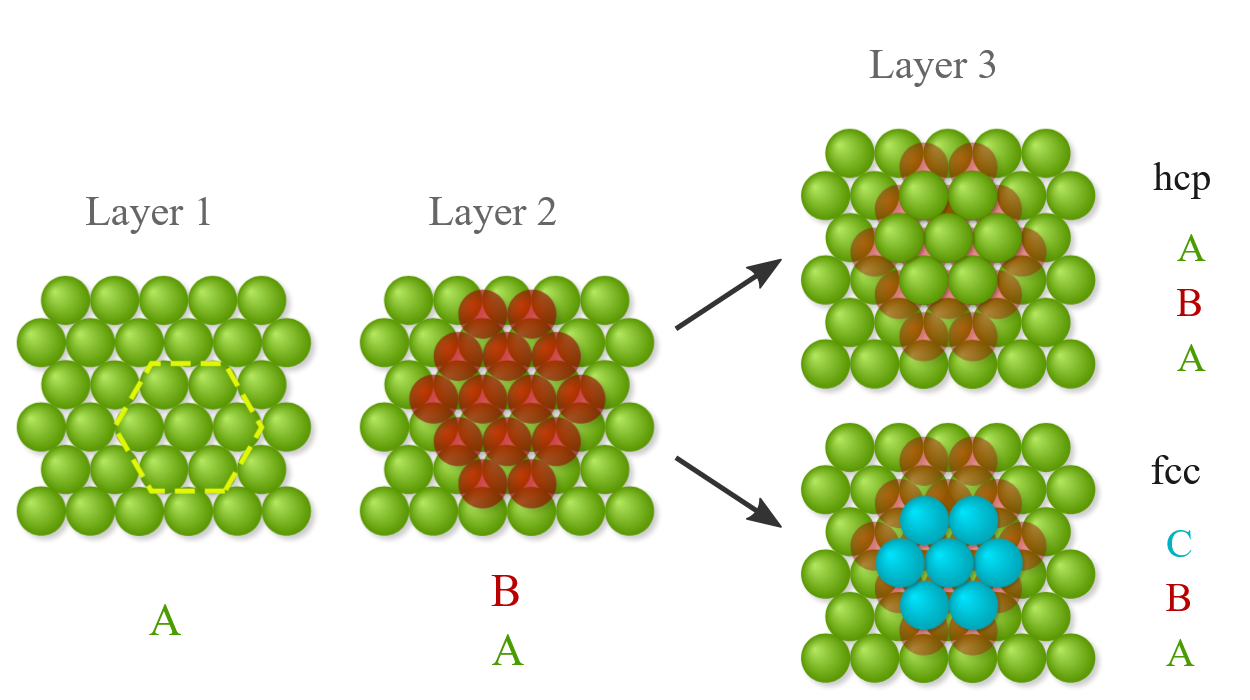
from: https://www.physics-in-a-nutshell.com/article/11/close-packed-structures-fcc-and-hcp

In [4]:
from IPython.display import HTML
HTML(filename="dia_100_app/diamond_graphite_stacking.html")

## Importing the model's weigths

In [4]:
# =============================================================================
# import PANNA weights
configfile = 'dia_100_app/train_diamond/train.ini' # 'div_app/train_diverse/mytrain_diverse.ini' # 
pcalc = PANNAJAXCalculator(config=configfile) #, weights_file='epoch_930_step_93000.pkl') 
sc.calc = pcalc
# =============================================================================

INFO - reading dia_100_app/train_diamond/train.ini
INFO - Getting model dia_100_app/train_diamond/models/epoch_2500_step_250000.pkl


## Relaxing the structure

In [6]:
# =============================================================================
# relaxation
print('Initial stress [ev/A^3]:', sc.get_stress())
sf = StrainFilter(sc) 
relax = BFGS(sf)
relax.run(fmax=1e-09, steps=50)
Erelax = sc.get_potential_energy() #* 1/Ha_to_ev
Frelax = sc.get_forces() #/ CONV_FACT_f 
stressrelax = sc.get_stress()
SCellrelax = sc.get_cell()
# R = sc.get_positions()

# print(np.linalg.norm(R-R0, axis=1).max())
print('Max force component [ev/A]:', abs(Frelax).max())
print('stress [ev/A^3]:', stressrelax)
alat_relax = (4*SCellrelax.volume)**(1/3)
alpha, beta, gamma = SCellrelax.angles()
print('alat [A]:', alat_relax/4)
print('alpha, beta, gamma [deg]:', alpha, beta, gamma)

#view(sc)
# =============================================================================

Initial stress [ev/A^3]: [-8.70770569e-02 -8.70770569e-02 -8.70770569e-02 -4.09549501e-17
  3.16566025e-17  2.20418208e-17]
      Step     Time          Energy          fmax
BFGS:    0 15:10:14    -4065.990573       13.933226
BFGS:    1 15:10:15    -4053.358849      103.386479
BFGS:    2 15:10:15    -4066.134151        3.778185
BFGS:    3 15:10:15    -4066.138374        2.378322
BFGS:    4 15:10:15    -4066.141526        0.080729
BFGS:    5 15:10:15    -4066.141529        0.001998
BFGS:    6 15:10:15    -4066.141529        0.000002
BFGS:    7 15:10:15    -4066.141529        0.000000
Max force component [ev/A]: 6.316039745791861e-14
stress [ev/A^3]: [-2.36904146e-12  4.49146481e-12 -2.63742684e-12 -4.21940393e-15
  3.78848526e-15  2.53654377e-15]
alat [A]: 1.8143469884371202
alpha, beta, gamma [deg]: 60.000000000022894 59.999999999951385 60.00000000002564


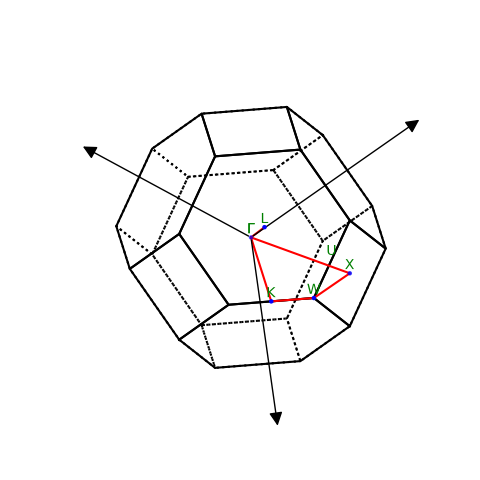

[[0.    0.    0.   ]
 [0.5   0.    0.5  ]
 [0.5   0.25  0.75 ]
 [0.375 0.375 0.75 ]
 [0.    0.    0.   ]
 [0.5   0.5   0.5  ]]


In [7]:
%matplotlib widget

path = sc.cell.bandpath("GXWKGL", npoints=6)
path.plot(show=True)
print(path.kpts)

# Computing phonons

In [5]:
# =============================================================================
# Phonons
kinput_scaled = np.array([
    [0.000, 0.000, 0.000],   # Γ
    [0.500, 0.000, 0.500],   # X
    [0.500, 0.250, 0.750],   # W
    [0.375, 0.375, 0.750],   # K
    [0.000, 0.000, 0.000],   # Γ
    [0.500, 0.500, 0.500]    # L
])
labels = [r'$\Gamma$', 'X', 'W', 'K', r'$\Gamma$', 'L']
interp = 20
tol = 1e-4
asr = True
dx_and_sx = False
save_freqs_eigvecs = False
connect_bands = True
verbose = True
appendix = ''
inputs_phonons = (natuc, N1, N2, N3, kinput_scaled, labels, interp, masses)
x, xcom, xlabels, kps_sc, kps, frequencies_list, eigvecs_list, Ds_list, K = get_phonons(sc, inputs_phonons, asr=asr, dx_and_sx=dx_and_sx, save_freqs_eigvecs=save_freqs_eigvecs, appendix=appendix, tol=tol, connect_bands=connect_bands, verbose=verbose)
# =============================================================================

Max initial force
[1.56060061e-14 1.99359325e-14 3.51905462e-14]
Will displace atoms of [A]  0.001
Displacing atom 0 in direction 0
Displacing atom 0 in direction 1
Displacing atom 0 in direction 2
Displacing atom 1 in direction 0
Displacing atom 1 in direction 1
Displacing atom 1 in direction 2
The k point [0.375 0.375 0.75 ] provided is not compatible with the supercell. 
Try again :)
	 processing k-point: 0 [0. 0. 0.]
	 processing k-point: 1 [0.024 0.    0.024]
	 processing k-point: 2 [0.048 0.    0.048]
	 processing k-point: 3 [0.071 0.    0.071]
	 processing k-point: 4 [0.095 0.    0.095]
	 processing k-point: 5 [0.119 0.    0.119]
	 processing k-point: 6 [0.143 0.    0.143]
	 processing k-point: 7 [0.167 0.    0.167]
	 processing k-point: 8 [0.19 0.   0.19]
	 processing k-point: 9 [0.214 0.    0.214]
	 processing k-point: 10 [0.238 0.    0.238]
	 processing k-point: 11 [0.262 0.    0.262]
	 processing k-point: 12 [0.286 0.    0.286]
	 processing k-point: 13 [0.31 0.   0.31]
	 pro

## Plotting the dispersion

(Text(0, 0.5, 'THz'), Text(0.5, 1.0, 'Phonons in diamond'))

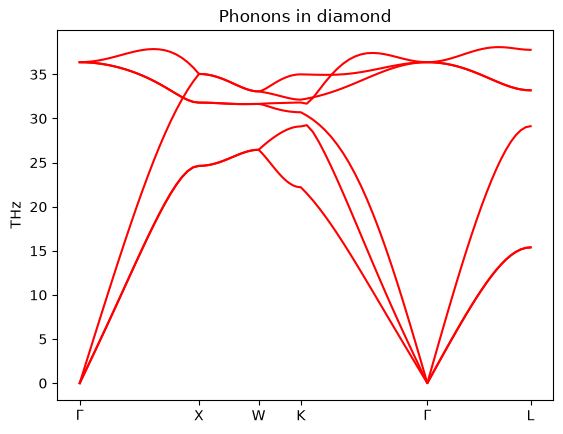

In [6]:
# =============================================================================
# band plotting
fig,ax = plt.subplots()
for i in range(natuc*3):
   nn, = ax.plot(x, frequencies_list[i], c='r', label='')#, marker='o', )
ax.set_xticks(xcom), ax.set_xticklabels(xlabels)
ax.set_ylabel('THz'), ax.set_title('Phonons in diamond')
# plt.savefig('aaa.pdf')
# =============================================================================

## Viewing eigenvectors of acoustic modes

Every 3D crystal has exactly **three acoustic branches**, regardless of how many atoms are in the unit cell. Exactly at $\Gamma$, they correspond to the three ways all atoms in the cell can rigidly translate together. Near $\Gamma$ ($q \to 0$), what do they look like? What do they correspond to?

# ===============================
Kpoint cartesian [ 0.      0.0834 -0.    ] Mode 1; frequency: 1.3477 THz

Real eigenvector:
[[ 1.4424e+00 -3.0000e-04  1.4424e+00]
 [ 1.4423e+00 -3.0000e-04  1.4423e+00]]
Imaginary eigenvector:
[[ 0.     -0.0408 -0.    ]
 [-0.0214 -0.0408 -0.0214]]
# ===============================


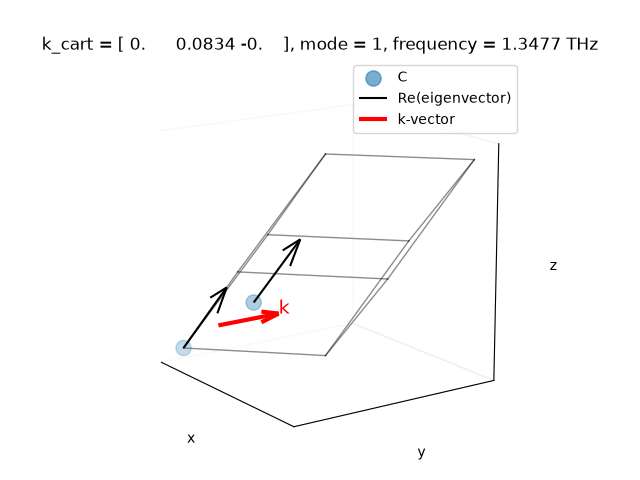

In [8]:
%matplotlib widget
ik, n = 1, 1 # second k-point, third mode
kpt = kps[ik]
omega = frequencies_list[n,ik]
eigvec = eigvecs_list[ik,:,n]
plot_phonon_mode(
    k_cart=kpt,
    n=n,
    omega=omega,
    eigvec=eigvec,
    Ruc=uc.get_positions(),
    Cell=uc.get_cell().array,
    masses=uc.get_masses(),
    symbols=uc.get_chemical_symbols(),
    ampl=10,
    repeat=(1,1,1),
    k_scale=0.5,
    #show_imag=True,
)

# Relationship acoustic phonons at $q \to 0$ - elasticity

## 1. Uniaxial strain

Consider a 1D elastic rod (or a 1D atomic chain, in the continuum limit)
lying along $x$, with a displacement field $u(x)$ describing how each point
of the material is displaced from its equilibrium position.

The **uniaxial strain** of an infinitesimal volume element at point $x$ is the local relative stretching:

$$
\varepsilon_{xx}(x) \equiv \frac{du}{dx}
$$

It is dimensionless: it tells you by what *fraction* a small segment of
material has been stretched, not by how much in absolute terms.

## 2. Energy as force times displacement: $dE = F\,du$

Now imagine slowly, quasi-statically, displacing the end face of a small
volume element (cross-section $A$) by an extra amount $du$, while an
internal force $F$ resists/drives that displacement. The incremental work
done on the element — which becomes stored elastic energy — is simply:

$$
dE = F\, du
$$

## 3. Energy density: $dE/V = \sigma_{xx}\,\varepsilon_{xx}$

Divide the work by the volume of the element, $V = A\,dx$, and define the
**stress** as force per unit area, $\sigma_{xx} \equiv F/A$:

$$
\frac{dE}{V} = \frac{F\,du}{A\,dx} = \sigma_{xx}\,\frac{du}{dx}
= \sigma_{xx}\,\varepsilon_{xx}
$$

So the elastic energy *density* obeys the differential relation

$$
\frac{dE}{V} = \sigma_{xx}\,d\varepsilon_{xx}
\qquad\Longleftrightarrow\qquad
\sigma_{xx} = \frac{\partial E/V}{\partial \varepsilon_{xx}}
$$

which is precisely the thermodynamic definition of stress as the variable
conjugate to strain (identical in spirit to $F = -dV/dx$ for a point
particle).

Now impose **Hooke's law**, $\sigma_{xx} = C_{11}\,\varepsilon_{xx}$, and
integrate:

$$
\frac{E(\varepsilon_{xx})}{V} = \tfrac{1}{2} C_{11}\, \varepsilon_{xx}^2
$$

$C_{11}$ is literally the curvature ($d^2\frac{E}{V}/d\varepsilon_{xx}^2$) of the
elastic energy landscape — the stiffness of the material against uniaxial
strain.

## 4. From energy to force: $f = -\partial E/\partial u$

The *net* force on a small element comes from the **imbalance**
of stress pulling on its two opposite faces — i.e. from how much $\sigma_{xx}$
changes from one side of the element to the other. Dividing by the volume
$A\,dx$ gives the **force per unit volume**:

$$
\frac{f}{V} = \frac{d\sigma_{xx}}{dx} = C_{11}\,\frac{d^2u}{dx^2}
$$



## 5. Equation of motion

Newton's second law $F = m a$ in a continuum can be considered per unit volume, $\rho\,\ddot u = \frac{f}{V}$, giving the 1D elastic wave equation:

$$
\rho\,\frac{\partial^2 u}{\partial t^2} = C_{11}\,\frac{\partial^2 u}{\partial x^2}
$$

Try a plane-wave (phonon) ansatz $u(x,t) = e\,\exp[i(qx-\omega t)]$. We get the 1d eigenvalue problem
$$
\rho\,\omega^2 e = C_{11}\,q^2 e
$$

$$
\rho\,\omega^2 = C_{11}\,q^2
\qquad\Longrightarrow\qquad
\boxed{\;\omega = v_s\, q\,, \qquad \rho v_s^2 = C_{11}\;}
$$

This is a straight line through the origin: **linear dispersion**, exactly
what an acoustic phonon branch looks like as $q\to 0$. Note that the initial
slope of the dispersion is entirely fixed by the macroscopic combination
$C_{11}/\rho$.


## 5. Generalizing to higher dimension
It can be shown (see e.g. Dove, Introduction to Lattice Dynamics, ch. 7) that in higher dimensions the equation of motion becomes the eigenvalue problem
$$
\rho \omega^2 \mathbf{e} = \mathbf{M} \cdot \mathbf{e}
$$
where $\mathbf{M}$ is the Christoffel matrix
$$
M_{ik} = \sum_{jl} C_{ijkl} k_j k_l
$$

It can be shown that the maximum number of independent elastic constants is 21, for the least symmetric crystal.
In a cubic crystal only 3 of them survive.
In Voigt notation ($xx \to 1, \quad yy \to 2, \quad zz \to 3, \quad xy,yz \to 6, \quad xz,zx \to 5, \quad yz,zy \to 4$), they are
$$
\mathbf{C} =
\begin{pmatrix}
C_{11} & C_{12} & C_{12} & 0 & 0 & 0 \\
C_{12} & C_{11} & C_{12} & 0 & 0 & 0 \\
C_{12} & C_{12} & C_{11} & 0 & 0 & 0 \\
0 & 0 & 0 & C_{44} & 0 & 0 \\
0 & 0 & 0 & 0 & C_{44} & 0 \\
0 & 0 & 0 & 0 & 0 & C_{44}
\end{pmatrix}
$$

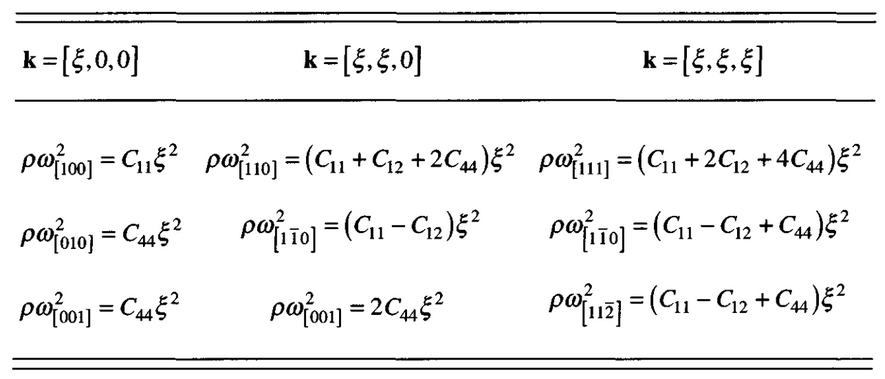

Table with the relations acoustic frequencies at $q\to 0$ and elastic constants in a cubic crystal for different directions of propagations $\mathbf{k}$, from Dove, Introduction to Lattice Dynamics.

Q.: $C_{44}$ is the stiffness with respect to a shear. Can you guess why it is related to $\omega_{\text{TA}}$?

# Computing phonons with ASE

In [12]:
from ase.phonons import Phonons
# =============================================================================
# import PANNA weights
configfile = 'dia_100_app/train_diamond/train.ini' # 'div_app/train_diverse/mytrain_diverse.ini' # 
pcalc = PANNAJAXCalculator(config=configfile) #, weights_file='epoch_930_step_93000.pkl') 
uc.calc = pcalc
# =============================================================================
# =============================================================================
# relaxation
print('Initial stress [ev/A^3]:', uc.get_stress())
sf = StrainFilter(uc) 
relax = BFGS(sf)
relax.run(fmax=1e-09, steps=50)
# =============================================================================
# =============================================================================
# ASE phonons

# 1. finite-displacement force calculations
ph = Phonons(uc, uc.calc, supercell=(4,4,4), delta=0.001)
ph.run()

# 2. read force constants
ph.read(acoustic=True)

# 3. define path: Γ-X-W-K-Γ-L
path = sc.cell.bandpath("GXWKGL", npoints=50)

# 4. phonon band structure
bs = ph.get_band_structure(path, verbose=True)

INFO - reading dia_100_app/train_diamond/train.ini
INFO - Getting model dia_100_app/train_diamond/models/epoch_2500_step_250000.pkl
Initial stress [ev/A^3]: [-8.70770569e-02 -8.70770569e-02 -8.70770569e-02 -6.76596613e-17
 -1.30507531e-16 -1.12849428e-16]
      Step     Time          Energy          fmax
BFGS:    0 15:12:29     -508.248822        1.741653
BFGS:    1 15:12:29     -508.266098        0.624280
BFGS:    2 15:12:29     -508.267592        0.150472
BFGS:    3 15:12:29     -508.267691        0.006144
BFGS:    4 15:12:29     -508.267691        0.000073
BFGS:    5 15:12:29     -508.267691        0.000000
BFGS:    6 15:12:29     -508.267691        0.000000
WARNING, 2 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 4.550e-07*i)
WARNING, 2 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 4.550e-07*i)


13

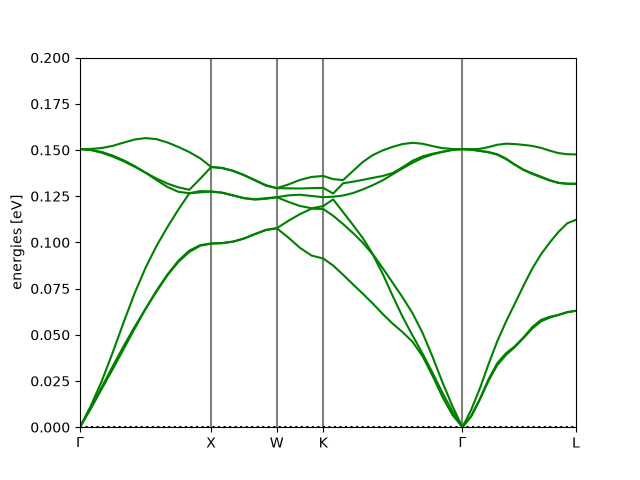

In [13]:
# 5. plot
bs.plot(emin = 0, emax=0.20)

# Dlist = ph.D_N
ph.clean()
# =============================================================================

## Visualizing phonons with ASE

In [14]:
# let's see the first 5 kpts
print(path.kpts[0:5])

[[0.         0.         0.        ]
 [0.04166667 0.         0.04166667]
 [0.08333333 0.         0.08333333]
 [0.125      0.         0.125     ]
 [0.16666667 0.         0.16666667]]


In [15]:
ph = Phonons(uc, uc.calc, supercell=(4,4,4), delta=0.001, name='dia_100_app/phonon_ase')
ph.read()
qp = path.kpts[1]

ph.write_modes(
    q_c=qp,
    branches=[4],          # 0-based branch index
    repeat=(1,1,1),        # visualize a larger supercell
    kT=3e-0,               # sets the displacement amplitude
    center=True
)

In [16]:
!ase gui dia_100_app/phonon_ase.mode.4.traj

/home/gabriele/miniconda3/envs/tutorial/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [ ]:
!ls dia_100_app

# Computing the Bulk modulus

The Bulk modulus is
$$
B = - V \frac{dP}{dV} = V \frac{d^2 E}{dV^2}
$$
There are therefore two ways to compute it:
1) from the change of P as a function of V, P(V)
2) from the energy as a function of V, E(V)

In [17]:
# =============================================================================
# create unit cell and supercell
uc = bulk('C','diamond', a=3.588, cubic=False) 
#uc = read_vasp('POSCARS/POSCAR_graphite')
Cell = np.array(uc.get_cell())
# view(uc)
# =============================================================================

In [18]:
# =============================================================================
# import PANNA weights
configfile = 'dia_100_app/train_diamond/train.ini'
pcalc = PANNAJAXCalculator(config=configfile,
                          weights_file=-1)#'epoch_930_step_93000.pkl') 
uc.calc = pcalc
# =============================================================================

INFO - reading dia_100_app/train_diamond/train.ini
INFO - Getting model dia_100_app/train_diamond/models/epoch_2500_step_250000.pkl


In [19]:
# =============================================================================
# relaxation
evA3_to_GPa = 160.21766
print('Initial stress [GPa]:', uc.get_stress()*evA3_to_GPa)
sf = StrainFilter(uc) # StrainFilter
relax = BFGS(sf)
relax.run(fmax=1e-07, steps=20)
# Then we can collect info on the relaxed structure
Erelax = uc.get_potential_energy() 
Frelax = uc.get_forces() 
stressrelax = uc.get_stress()
Cellrelax = uc.get_cell()
# R = uc.get_positions()

# print(np.linalg.norm(R-R0, axis=1).max())
print('Max force component [ev/A]:', abs(Frelax).max())
print('relaxed stress [Gpa]:', stressrelax*evA3_to_GPa)
alat_relax = (4*Cellrelax.volume)**(1/3)
alpha, beta, gamma = Cellrelax.angles()
print('alat [A]:', alat_relax)
print('alpha, beta, gamma [deg]:', alpha, beta, gamma)
#view(sc)
# =============================================================================

Initial stress [GPa]: [-1.39512823e+01 -1.39512823e+01 -1.39512823e+01 -1.08402726e-14
 -2.09096112e-14 -1.80804713e-14]
      Step     Time          Energy          fmax
BFGS:    0 15:14:20     -508.248822        1.741653
BFGS:    1 15:14:20     -508.266098        0.624280
BFGS:    2 15:14:20     -508.267592        0.150472
BFGS:    3 15:14:20     -508.267691        0.006144
BFGS:    4 15:14:20     -508.267691        0.000073
BFGS:    5 15:14:20     -508.267691        0.000000
Max force component [ev/A]: 2.8228355525468374e-15
relaxed stress [Gpa]: [-2.61642586e-07 -2.61642596e-07 -2.61642513e-07  2.30634030e-14
  3.41207794e-14  4.64779997e-14]
alat [A]: 3.628693976263518
alpha, beta, gamma [deg]: 59.99999999999999 59.99999999999999 59.99999999999999


## Pressure from stress tensor
The pressure is the isotropic part of the stress tensor,
$$
P = - \frac{1}{3} \sum_i \sigma_{ii}
$$
Let's approximate $dP/dV$ by finite difference

In [20]:
# =============================================================================
# Compute Bulk modulus from stresses 
Cell0 = uc.get_cell().array.copy()
V0 = uc.get_volume()

eps = 1e-4   # try 1e-3 to 5e-3

def pressure_at_scale(scale):
    uc.set_cell(scale * Cell0, scale_atoms=True)
    stress = uc.get_stress(voigt=False)
    return -np.trace(stress) / 3   # ASE pressure convention

P_plus = pressure_at_scale(1 + eps)
V_plus = uc.get_volume()

P_minus = pressure_at_scale(1 - eps)
V_minus = uc.get_volume()

B = -V0 * (P_plus - P_minus) / (V_plus - V_minus) * evA3_to_GPa

print('# =======================================')
print('Bulk modulus from stress [GPa] ', B)
print('# =======================================')

# reset original undistorted cell
uc.set_cell(Cell0, scale_atoms=True)
# =============================================================================

# =======================================
Bulk modulus from stress [GPa]  518.1373264888537
# =======================================


## Alternative calculation

In [ ]:
# two typical EOS functions
def murnagham(V, V0, E0, K0, K1):
    return E0 + K0*V0 * ( 1/(K1*(K1-1))*(V/V0)**(1-K1) + V/(V0*K1) - 1/(K1-1) )

def birch_murnagham(V, V0, E0, K0, K1):
    return E0 + 9/16*V0*K0 * ( ((V0/V)**(2/3) -1)**3 * K1 + ((V0/V)**(2/3) -1)**2 * (6-4*(V0/V)**(2/3)) )

In [ ]:
# =============================================================================
# Calculating E(V)
du = 0.001
dus = np.arange(-0.01, 0.01, du)

energies, vols, alats = [], [], []
for i,du in enumerate(dus):
    eps = np.array([[du,0,0],[0,du,0],[0,0,du]])
    Celld = (np.eye(3) + eps) @ Cell0
    vold = np.linalg.det(Celld)
    uc.set_cell(Celld, scale_atoms=True)
    
    # relaxation
    #relax = BFGS(sc)
    #relax.run(fmax=1e-09, steps=20)
    energyd = float(uc.get_potential_energy())
    
    energies.append(energyd)
    vols.append(vold)
    alats.append((4*vold)**(1/3) )
energies, vols, alats = np.array(energies), np.array(vols), np.array(alats)
# =============================================================================

In [ ]:
# =============================================================================
# Fitting
from scipy.optimize import curve_fit

init_B0 = 300

# # fitting to polynomial
# max_deg = 5
# z = np.polyfit(vol, energy, max_deg)
# p = np.poly1d(z)
# vs = np.arange(vol.min(), vol.max(), 0.001)
# es = p(vs)
# index_min = np.argwhere(p(vs) == p(vs).min())
# V0 = vs[index_min] 
# B = V0 * p[2] * evA3_to_GPa
# print(B)


#fitting to Murnagham
popt1, pcov1, info, mesg, ier = curve_fit(murnagham, vols, energies, p0=[vols.mean(), energies.min(), init_B0, 100], full_output=True)
# res = least_squares(murnagham, vol, args=[vol.mean(), energy.min(), 400,100])#, energy)#, p0=[], full_output=True)
perr1 = np.sqrt(np.diag(pcov1))
lsq1 = np.sqrt( np.mean( (murnagham(vols, *popt1) - energies)**2))
V1 = popt1[0]
B1 = popt1[2] * evA3_to_GPa


#fitting to Birch-Murnagham
popt2, pcov2 = curve_fit(birch_murnagham, vols, energies, p0=[vols.mean(), energies.min(), init_B0 ,100], full_output=False)
perr2 = np.sqrt(np.diag(pcov2))
lsq2 = np.sqrt( np.mean( (birch_murnagham(vols, *popt2) - energies)**2))
V2 = popt2[0]
B2 = popt2[2] * evA3_to_GPa

print('# =======================================')
print('Fitting to Murnagham eos:')
print('Bulk modulus [GPa]', B1)
print('Equilibrium volume [A^3] ', V1)
print('Equilibrium lattice param [A]', (4*V1)**(1/3))
print('RMSE: ', lsq1)
print("Error in the parameters V0, E0, K0, K1 ", perr1)
print((V1*8)**(1/3))

print('# =======================================')
print('Fitting to Birch-Murnagham eos')
print('Bulk modulus [GPa]', B2)
print('Equilibrium volume [A^3] ', V2)
print('Equilibrium lattice param [A]', (4*V2)**(1/3))
print('RMSE: ', lsq2)
print("Error in the parameters V0, E0, K0, K1 ", perr2)
print((V2*8)**(1/3))

# save eos to file
#vvols = np.linspace(vols.min(), vols.max(), 100)
#nvols = len(vvols)
#B = np.zeros((nvols,4))
#B[:,0], B[:,1], B[:,2], B[:,3]  = range(nvols), vvols, murnagham(vvols, *popt1), birch_murnagham(vvols, *popt2) 
#with open('vol_vs_energy.txt', 'ab') as f:
#    f.write(b'\n\n')
#    np.savetxt(f, B)

# # saving to file for ev.x of qe
# C = np.zeros_like(A)
# C[:,0], C[:,1] = vol, energy*ev_to_Ry
# np.savetxt('vvse', C)


fig,ax = plt.subplots()
ax.scatter(vols, energies, label='calculated')
# ax.plot(vs, p(vs))
vs = np.arange(vols.min(), vols.max(), 0.001)
ax.plot(vs, murnagham(vs, *popt1), label='Murnagham B='+str(np.round(B1,2)))
ax.plot(vs, birch_murnagham(vs, *popt2), label='Birch-Murnagham B='+str(np.round(B2,2)))

ax.set_xlabel('volume [A$^3$]')
ax.set_ylabel('energy [ev]')
ax.legend()
ax.set_title('Bulk modulus')
# fig.savefig('Bulk_modulus.png')
# =============================================================================

# Computing the elastic constants

Remember that the elastic constants are simply the derivatives of the stress with respect to the strain. For example,
$$
C_{11} = \frac{d \sigma_{1}}{d \epsilon_1} = \frac{d \sigma_{xx}}{d \epsilon_{xx}}
$$
and remember that the strain is a transformation of the cell $\mathbf{h} \to (\mathbb{1} + \mathbf{\epsilon}) \cdot \mathbf{h}$

Assignment. Write the code to compute $C_{11}$ of diamond. 

In [21]:
# =============================================================================
# from stresses 
Cell0 = uc.get_cell().array.copy()
V0 = uc.get_volume()
stress0 = uc.get_stress()

deps = 1e-5   # try 1e-3 to 5e-3
eps = np.array([[deps, 0, 0], [0,0,0], [0,0,0]])
Celld = Cell0 @ (np.eye(3) + eps)
uc.set_cell(Celld, scale_atoms=True)
stressd = uc.get_stress()

C11 = (stressd[0] - stress0[0]) / (deps) * evA3_to_GPa
C12 = (stressd[1] - stress0[1]) / (deps) * evA3_to_GPa


print('C11 [GPa]:', C11)
print('C12 [GPa]:', C12)
# reset original undistorted cell
uc.set_cell(Cell0, scale_atoms=True)
# =============================================================================

C11 [GPa]: 1027.0324291277536
C12 [GPa]: 263.7277923258573


# Running MD

In [22]:
# =============================================================================
# MD
from ase.io.trajectory import Trajectory
from ase.md import VelocityVerlet, Andersen
from ase.md.nose_hoover_chain import NoseHooverChainNVT
from ase.md.nptberendsen import NPTBerendsen
from ase.md.nose_hoover_chain import IsotropicMTKNPT
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
from ase import units
import time

# =============================================================================
# create unit cell and supercell
uc = bulk('C','diamond', a=3.588, cubic=False) 
# uc = read_vasp('dia_100_app/POSCARS/POSCAR_graphite')
natuc = uc.get_global_number_of_atoms() 
N1, N2, N3 = 2,2,2
sc = make_supercell(uc, [[N1, 0, 0], [0, N2, 0], [0, 0, N3]])
configfile = 'dia_100_app/train_diamond/train.ini'
pcalc = PANNAJAXCalculator(config=configfile,
                          weights_file=-1)#'epoch_930_step_93000.pkl') 
sc.calc = pcalc
# =============================================================================

INFO - reading dia_100_app/train_diamond/train.ini
INFO - Getting model dia_100_app/train_diamond/models/epoch_2500_step_250000.pkl


In [23]:
# =============================================================================
# NVE simulation
def printenergy(a=sc):  # store a reference to atoms in the definition.
    """Function to print the potential, kinetic and total energy."""
    epot = a.get_potential_energy() / len(a)
    ekin = a.get_kinetic_energy() / len(a)
    print(
        f'Energy per atom: Epot ={epot:6.3f}eV  Ekin = {ekin:.3f}eV '
        f'(T={ekin / (1.5 * units.kB):3.0f}K) Etot = {epot + ekin:.3f}eV'
    )


# NVE
t0 = time.time()
dyn = VelocityVerlet(sc, 1 * units.fs, 
                     # trajectory='NVE.traj',
                     logfile='nve.log')
traj = Trajectory('NVE.traj', 'w', sc)
dyn.attach(traj.write, interval=10)
dyn.attach(printenergy, interval=10)
dyn.run(1000)  # take 1000 steps
t1 = time.time()
print('seconds to run 1000 steps NVE', t1-t0)
# =============================================================================

Energy per atom: Epot =-254.124eV  Ekin = 0.000eV (T=  0K) Etot = -254.124eV
Energy per atom: Epot =-254.124eV  Ekin = 0.000eV (T=  0K) Etot = -254.124eV
Energy per atom: Epot =-254.124eV  Ekin = 0.000eV (T=  0K) Etot = -254.124eV
Energy per atom: Epot =-254.124eV  Ekin = 0.000eV (T=  0K) Etot = -254.124eV
Energy per atom: Epot =-254.124eV  Ekin = 0.000eV (T=  0K) Etot = -254.124eV
Energy per atom: Epot =-254.124eV  Ekin = 0.000eV (T=  0K) Etot = -254.124eV
Energy per atom: Epot =-254.124eV  Ekin = 0.000eV (T=  0K) Etot = -254.124eV
Energy per atom: Epot =-254.124eV  Ekin = 0.000eV (T=  0K) Etot = -254.124eV
Energy per atom: Epot =-254.124eV  Ekin = 0.000eV (T=  0K) Etot = -254.124eV
Energy per atom: Epot =-254.124eV  Ekin = 0.000eV (T=  0K) Etot = -254.124eV
Energy per atom: Epot =-254.124eV  Ekin = 0.000eV (T=  0K) Etot = -254.124eV
seconds to run 1000 steps NVE 2.341493844985962


## What happened?

In [ ]:
!ase gui NVE.traj

## Rumping up temperature!

In [24]:
# =============================================================================
# Let's rump up the Temperature!
MaxwellBoltzmannDistribution(sc, temperature_K=1000)
Stationary(sc)               # remove center-of-mass drift
def printenergy(a=sc):  # store a reference to atoms in the definition.
    """Function to print the potential, kinetic and total energy."""
    epot = a.get_potential_energy() / len(a)
    ekin = a.get_kinetic_energy() / len(a)
    print(
        f'Energy per atom: Epot ={epot:6.3f}eV  Ekin = {ekin:.3f}eV '
        f'(T={ekin / (1.5 * units.kB):3.0f}K) Etot = {epot + ekin:.3f}eV'
    )
print('T at start [K]:', sc.get_temperature())  # before starting NVE

# Complete this cell to run 1000 steps of NVE
dyn = VelocityVerlet(sc, 1 * units.fs, 
                     # trajectory='NVE.traj',
                     logfile='nve.log')
traj = Trajectory('NVE.traj', 'w', sc)
dyn.attach(traj.write, interval=10)
dyn.attach(printenergy, interval=10)
dyn.run(1000)  # take 1000 steps
# =============================================================================

/home/gabriele/tmp/ipykernel_4066/4265198202.py:3: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(sc, temperature_K=1000)


T at start [K]: 953.7610403255452
Energy per atom: Epot =-254.124eV  Ekin = 0.123eV (T=954K) Etot = -254.001eV
Energy per atom: Epot =-254.037eV  Ekin = 0.036eV (T=282K) Etot = -254.000eV
Energy per atom: Epot =-254.036eV  Ekin = 0.036eV (T=279K) Etot = -254.000eV
Energy per atom: Epot =-254.099eV  Ekin = 0.098eV (T=756K) Etot = -254.001eV
Energy per atom: Epot =-254.057eV  Ekin = 0.056eV (T=434K) Etot = -254.001eV
Energy per atom: Epot =-254.046eV  Ekin = 0.045eV (T=352K) Etot = -254.000eV
Energy per atom: Epot =-254.075eV  Ekin = 0.074eV (T=574K) Etot = -254.001eV
Energy per atom: Epot =-254.055eV  Ekin = 0.054eV (T=418K) Etot = -254.001eV
Energy per atom: Epot =-254.064eV  Ekin = 0.063eV (T=486K) Etot = -254.001eV
Energy per atom: Epot =-254.064eV  Ekin = 0.063eV (T=487K) Etot = -254.001eV
Energy per atom: Epot =-254.064eV  Ekin = 0.063eV (T=490K) Etot = -254.001eV


True

In [25]:
!ase gui NVE.traj

In [27]:
# =============================================================================
# create unit cell and supercell
uc = bulk('C','diamond', a=3.588, cubic=False) 
N1, N2, N3 = 2,2,2
sc = make_supercell(uc, [[N1, 0, 0], [0, N2, 0], [0, 0, N3]])
configfile = 'dia_100_app/train_diamond/train.ini'
pcalc = PANNAJAXCalculator(config=configfile,
                          weights_file=-1)#'epoch_930_step_93000.pkl') 
sc.calc = pcalc


# relaxation
relax = BFGS(sc)
relax.run(fmax=1e-09, steps=10)

INFO - reading dia_100_app/train_diamond/train.ini
INFO - Getting model dia_100_app/train_diamond/models/epoch_2500_step_250000.pkl
      Step     Time          Energy          fmax
BFGS:    0 15:18:50    -4065.990573        0.000000


np.True_

In [28]:
t0 = time.time()
#MaxwellBoltzmannDistribution(sc, temperature_K=500)
#print('T at start [K]:', sc.get_temperature())  # before starting NVT
def printenergy(a=sc):  # store a reference to atoms in the definition.
    """Function to print the potential, kinetic and total energy."""
    epot = a.get_potential_energy() / len(a)
    ekin = a.get_kinetic_energy() / len(a)
    print(
        f'Energy per atom: Epot ={epot:6.3f}eV  Ekin = {ekin:.3f}eV '
        f'(T={ekin / (1.5 * units.kB):3.0f}K) Etot = {epot + ekin:.3f}eV'
    )
Stationary(sc)               # remove center-of-mass drift
#nvt = NoseHooverChainNVT(sc, timestep=1*units.fs, 
#                         temperature_K=1000, 
#                             tdamp=100*units.fs, 
#                             tloop=1, tchain=1,
#                             logfile='nvt.log',
                             # trajectory='nvt.traj',     
#                             )

nvt = Andersen(sc, timestep=1.0*units.fs, 
               temperature_K=1000, 
               andersen_prob=1e-02,
               logfile='nvt.log', 
               # trajectory=None#'nvt.traj'
               )

traj = Trajectory('NVT.traj', 'w', sc)
nvt.attach(traj.write, interval=10)
nvt.attach(printenergy, interval=10)
nvt.run(1000)  # take 1000 steps
t1 = time.time()
print('seconds to run 1000 steps NVT', t1-t0)
# =============================================================================

Energy per atom: Epot =-254.124eV  Ekin = 0.000eV (T=  0K) Etot = -254.124eV
Energy per atom: Epot =-254.106eV  Ekin = 0.007eV (T= 53K) Etot = -254.099eV
Energy per atom: Epot =-254.102eV  Ekin = 0.017eV (T=135K) Etot = -254.084eV
Energy per atom: Epot =-254.096eV  Ekin = 0.028eV (T=213K) Etot = -254.068eV
Energy per atom: Epot =-254.095eV  Ekin = 0.030eV (T=233K) Etot = -254.065eV
Energy per atom: Epot =-254.086eV  Ekin = 0.035eV (T=270K) Etot = -254.051eV
Energy per atom: Epot =-254.065eV  Ekin = 0.045eV (T=346K) Etot = -254.020eV
Energy per atom: Epot =-254.068eV  Ekin = 0.067eV (T=518K) Etot = -254.001eV
Energy per atom: Epot =-254.059eV  Ekin = 0.069eV (T=536K) Etot = -253.990eV
Energy per atom: Epot =-254.050eV  Ekin = 0.062eV (T=476K) Etot = -253.988eV
Energy per atom: Epot =-254.054eV  Ekin = 0.070eV (T=540K) Etot = -253.984eV
Energy per atom: Epot =-254.069eV  Ekin = 0.078eV (T=601K) Etot = -253.991eV
Energy per atom: Epot =-254.020eV  Ekin = 0.054eV (T=419K) Etot = -253.966eV

In [29]:
!ase gui NVT.traj

In [30]:
# t1 = time.time()
# NPT simulation (1000K, 1 fs time step, atmospheric pressure)
npt = IsotropicMTKNPT(sc, 
                      timestep=1 * units.fs, 
                      temperature_K=1000,
                      pressure_au=1.01325 * units.bar,
                      tdamp = 100 * units.fs,
                      pdamp = 100 * units.fs,
                      logfile='npt.log',
                      trajectory='npt.traj')
                      # loginterval=100)

# # # NPT simulation (1000K, 1 fs time step, atmospheric pressure)
# # npt = NPTBerendsen(sc, 
# #                    timestep=1 * units.fs, 
# #                    temperature_K=1000,
# #                    taut=100 * units.fs, 
# #                    taup=100 * units.fs, 
# #                    pressure_au=1.01325 * units.bar,
# #                    compressibility_au=4.57e-5 / units.bar,
# #                    # trajectory='npt.traj',
# #                    logfile='npt.log',)

traj = Trajectory('npt.traj', 'w', sc)
npt.attach(printenergy, interval=100)
npt.attach(traj.write, interval=100)
npt.run(1000)
t2 = time.time()
print('seconds to run 1000 steps NPT', t2-t1)
# =============================================================================

Energy per atom: Epot =-254.034eV  Ekin = 0.095eV (T=738K) Etot = -253.939eV
Energy per atom: Epot =-254.027eV  Ekin = 0.116eV (T=899K) Etot = -253.910eV
Energy per atom: Epot =-254.010eV  Ekin = 0.135eV (T=1045K) Etot = -253.875eV


KeyboardInterrupt: 

In [ ]:
!cat 'npt.log'

In [31]:
!ase gui npt.traj